In [1]:
from dnallm import load_config, load_model_and_tokenizer
from dnallm import DNAInterpret, Mutagenesis

In [2]:
# Load configurations
configs = load_config("./inference_config.yaml")

In [3]:
# Load model and tokenizer
model_name = "zhangtaolab/plant-dnabert-BPE-promoter_strength_leaf"
model, tokenizer = load_model_and_tokenizer(model_name, task_config=configs['task'], source="modelscope")

2026-03-24 15:20:25,530 - modelscope - INFO - Not logged-in, you can login for uploadingor accessing controlled entities.


15:20:26 - dnallm.utils.support - INFO - Model files are stored in /home/liuguanqing/.cache/modelscope/hub/models/zhangtaolab/plant-dnabert-BPE-promoter_strength_leaf


In [4]:
interpreter = DNAInterpret(model, tokenizer, config=configs)

In [5]:
sequence = (
    "AATATATTTAATCGGTGTATAATTTCTGTGAAGATCCTCGATACTTCATATAAGAGATTTTGAGAGAGAGAGAGA"
    "ACCAATTTTCGAATGGGTGAGTTGGCAAAGTATTCACTTTTCAGAACATAATTGGGAAACTAGTCACTTTACTAT"
    "TCAAAATTTGCAAAGTAGTC"
)
sequences = [
    "AACACTCTATTTCGGGTATTGTCTCTGTGTTCCTTTAGCGGCGGCTTTACTTTAGATTCTTCTAGGGTTTCTAGA"
    "TTGTATACCCTAGATAAGCATCCTATAAAGTAAACACAAGTACTTGCAGAGACTTTAGATTAGAGGGCTAGCGAC"
    "TGCAGAAGAAGAGTAACACG",
    "TAAAGGAACATATTCCCGTCATAAAGAAAAGTTGACTATATTTAGCCCATGCAAAAAGAAAATAGATAAATTTAG"
    "AAATCTATATGCATATATTCCTTCTCAAGGGTTATAAAAAGAGAGCACATCCATGTGAGGAATGAGGCAACACAT"
    "ATTGAGAGTAATAAAGAGTA",
    "TTCACCAGCTAGGCCATAGTGCCGGCCCTTGCACAATGTTGTATCTGATCACCTAGCTAGTGTGAAGTGTTTGGA"
    "GGAACTCTAGGTGTTATCCAGCAATGTTTCATAGTTTGTGAAACTGTAAAAGGTTTTGGTAAGACGATGATCAGA"
    "TTTGGTGTTATCATGAGTTC",
]

In [6]:
tokens, lig_scores = interpreter.interpret(sequence, method="deeplift", target=0)

Auto-detected embedding layer at: bert.embeddings.word_embeddings


In [7]:
interpreter.plot_attributions(plot_type="token")

alt.LayerChart(...)

In [8]:
interpreter.plot_attributions(plot_type="line")

alt.LayerChart(...)

In [9]:
attributions = interpreter.batch_interpret(sequences, method="deeplift", targets=[0] * len(sequences))

In [10]:
interpreter.plot_attributions()

alt.Chart(...)

In [11]:
# Initialize in-silico mutagenesis analyzer
mutagenesis = Mutagenesis(config=configs, model=model, tokenizer=tokenizer)

In [12]:
mutagenesis.mutate_sequence(sequence, replace_mut=True)

Encoding inputs:   0%|          | 0/511 [00:00<?, ? examples/s]

In [13]:
preds = mutagenesis.evaluate()

15:20:53 - dnallm.utils.support - INFO - Using device: cpu


Inferring: 100%|██████████| 32/32 [08:18<00:00, 15.59s/it]
Evaluating mutations: 510it [00:00, 99211.31it/s]


In [14]:
preds

{'raw': {'sequence': 'AATATATTTAATCGGTGTATAATTTCTGTGAAGATCCTCGATACTTCATATAAGAGATTTTGAGAGAGAGAGAGAACCAATTTTCGAATGGGTGAGTTGGCAAAGTATTCACTTTTCAGAACATAATTGGGAAACTAGTCACTTTACTATTCAAAATTTGCAAAGTAGTC',
  'pred': array([2.2054496], dtype=float32),
  'logfc': array([0.]),
  'diff': array([0.]),
  'score': 0.0,
  'logits': 2.2054496},
 'mut_0_A_C': {'sequence': 'CATATATTTAATCGGTGTATAATTTCTGTGAAGATCCTCGATACTTCATATAAGAGATTTTGAGAGAGAGAGAGAACCAATTTTCGAATGGGTGAGTTGGCAAAGTATTCACTTTTCAGAACATAATTGGGAAACTAGTCACTTTACTATTCAAAATTTGCAAAGTAGTC',
  'pred': array([2.4706557], dtype=float32),
  'logfc': array([0.16382118], dtype=float32),
  'diff': array([0.2652061], dtype=float32),
  'score': 0.16382118,
  'score2': 0.2652061,
  'logits': 2.4706557},
 'mut_0_A_G': {'sequence': 'GATATATTTAATCGGTGTATAATTTCTGTGAAGATCCTCGATACTTCATATAAGAGATTTTGAGAGAGAGAGAGAACCAATTTTCGAATGGGTGAGTTGGCAAAGTATTCACTTTTCAGAACATAATTGGGAAACTAGTCACTTTACTATTCAAAATTTGCAAAGTAGTC',
  'pred': array([2.3904996], dtype=float32),
  'logfc': array([0

In [15]:
import pandas as pd
base_scores = mutagenesis.process_ism_data(preds)
hotspots = mutagenesis.find_hotspots(preds, window_size=10, percentile_threshold=90.0)
_, hyp_scores, _ = mutagenesis.prepare_tfmodisco_inputs([preds])
hyp_scores = hyp_scores[0]

hotspot_motifs = {}
for start, end in hotspots:
    hotspot_id = f"hotspot_{start}-{end}"
    # Extract the slice corresponding to the hotspot from hyp_scores
    motif_matrix = hyp_scores[start:end, :]
    motif_df = pd.DataFrame(motif_matrix, columns=['A', 'C', 'G', 'T'])
    hotspot_motifs[hotspot_id] = motif_df

Preparing inputs for TF-MoDISco...


In [16]:
def plot_motif_logo( motif_df: pd.DataFrame, logo_type: str = 'bits', title: str = "Discovered Motif" ):
    """ Plots a sequence logo from a motif matrix using Logomaker. """
    import logomaker
    import matplotlib.pyplot as plt
    print(f"Generating '{logo_type}' logo plot for: {title}")

    if logo_type == 'bits':
        logo_df = logomaker.transform_matrix(motif_df, from_type='probability', to_type='information')
        y_label = 'Bits'
    elif logo_type == 'weights':
        logo_df = motif_df
        y_label = 'Contribution Score'
    else: raise ValueError("logo_type must be 'bits' or 'weights'")
    logo = logomaker.Logo(logo_df, font_name='Arial Rounded MT Bold')
    logo.style_spines(visible=False)
    logo.style_spines(spines=['left', 'bottom'], visible=True)
    logo.ax.set_ylabel(y_label)
    logo.ax.set_title(title)
    plt.show()

Generating 'weights' logo plot for: Hotspot Motif


findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Ro

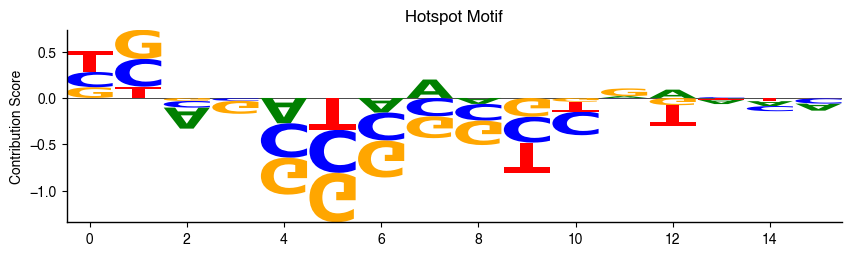

In [17]:
regions = list(hotspot_motifs.keys())
plot_motif_logo(hotspot_motifs[regions[0]], logo_type='weights', title="Hotspot Motif")